<a href="https://colab.research.google.com/github/romanrudniev/MachineLearning/blob/main/%D0%92%D1%81%D1%83%D0%BF_%D0%B4%D0%BE_NLP(%D0%9A%D0%BB%D0%B0%D1%81%D0%B8%D1%84%D1%96%D0%BA%D0%B0%D1%86%D1%96%D1%8F_%D0%B2%D1%96%D0%B4%D0%B3%D1%83%D0%BA%D1%96%D0%B2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Вступ до NLP

In [1]:
!pip install nltk

In [2]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('movie_reviews')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [3]:
from nltk.corpus.reader import documents
from nltk.corpus import movie_reviews
import random

documents = [(list(movie_reviews.words(fileid)),category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

random.shuffle(documents)

print(documents[10])

(['watching', 'the', 'movie', ',', 'i', 'vowed', 'to', 'subtract', 'half', 'a', 'star', 'from', 'the', 'review', 'because', 'the', 'filmmakers', 'included', 'a', 'saccharine', 'syrup', ',', 'cute', "'", 'n', 'cuddly', ',', 'computer', '-', 'generated', 'monkey', '.', 'if', 'the', 'monkey', 'died', ',', 'the', 'movie', 'got', 'an', 'extra', 'half', 'star', '.', 'alas', ',', 'the', 'monkey', 'showed', 'up', 'at', 'the', 'end', ',', 'unharmed', ',', 'to', 'the', 'wet', 'sickly', 'sound', 'of', 'gagging', 'and', 'rolling', 'eyeballs', '.', 'what', 'that', 'means', 'is', 'that', 'lost', 'in', 'space', 'actually', 'deserved', '2', 'stars', '.', 'that', "'", 's', 'pretty', 'generous', ',', 'considering', 'the', 'movie', "'", 's', 'camp', 'lacked', 'any', 'hint', 'of', 'tongue', 'in', 'cheek', '.', 'when', 'will', 'robinson', '(', 'jack', 'johnson', ')', 'teaches', 'his', 'pet', 'robot', 'about', 'friendship', ',', 'you', 'are', 'actually', 'supposed', 'to', 'buy', 'it', '.', 'so', 'why', 'suc

In [4]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clear_words(words: list) -> list:
  return [ps.stem(w.lower()) for w in words if w.isalpha() and w.lower() not in stop_words]

In [5]:
print(stop_words)

{"i'll", 'why', 'because', 'nor', 'on', 've', 'such', "aren't", 'my', 'not', 'after', 'few', 'hers', 'won', 'ours', "she'd", 'up', 'down', 'they', 'wouldn', 'it', 'and', "shan't", 'them', 'if', 'before', "you'll", 'yourself', 'mustn', 'am', 'yourselves', "he'd", 'its', 'over', 'mightn', "weren't", 'have', 'you', 'has', 'ourselves', 'had', "they'll", 'which', 'about', "i've", 'shouldn', 'further', 'there', 'most', "they've", 'are', "we'll", 'y', 'we', 'where', "haven't", 'each', 'more', "shouldn't", 't', 'him', "they'd", 'any', "couldn't", 'hadn', 'of', 'myself', 'once', 'no', 'during', 'into', 'when', 'our', 'her', 'does', 're', 'those', 'to', 'ma', "we'd", 'did', 'his', 'than', 'own', 'at', 'ain', "he'll", "it'll", 'having', 'above', 'an', 'until', 'by', 'again', "doesn't", 'haven', 'were', 'should', 'below', 'what', 'only', 'just', "didn't", 'himself', 'doing', "wouldn't", "i'm", 'some', 'didn', 'the', "it'd", 'll', 'so', 'these', "isn't", 'off', 'do', 'she', 'here', 'd', 'other', 't

In [6]:
cleaned_document = [(" ".join(clear_words(doc)), label) for doc, label in documents]

In [7]:
print(cleaned_document[10])

('watch movi vow subtract half star review filmmak includ saccharin syrup cute n cuddli comput gener monkey monkey die movi got extra half star ala monkey show end unharm wet sickli sound gag roll eyebal mean lost space actual deserv star pretti gener consid movi camp lack hint tongu cheek robinson jack johnson teach pet robot friendship actual suppos buy seemingli high rate reason made unabl throw away experi garbag first saw movi open night first day oper brand new theater sound screen kick ass nobodi countri enjoy movi much audienc necessarili mean good way also zero scene found root robinson get caught movi tension even like comput gener set usual prefer see model set cg detail seen lot movi look like someon spent littl overtim render futurist citi also gari oldman never bad actor even though typecast villain william hurt bad either neither actor great role perform watchabl perhap admit someth tone outlook movi brought back childhood littl swear blood strong moral messag saccharin 

In [9]:
df = pd.DataFrame(cleaned_document, columns=['reviev', 'label'])
df.head(10)

,reviev,label
0,wow film without redeem qualiti whatsoev amaz ...,neg
1,lengthi lousi two word describ bore drama engl...,neg
2,film tout explor relationship black sexual tro...,neg
3,saw advanc screen movi sniper last night say i...,neg
4,plot girl move top model fall love goofi lovea...,neg
5,concept jean claud van damm get kill within fi...,neg
6,strang day chronicl last two day lo angel loca...,pos
7,one side doom gloom documentari possibl annihi...,neg
8,pollock star ed harri marcia gay harden tom bo...,pos
9,bill feminist sex fantasi spirit imagin thorou...,pos


<Axes: title={'center': 'Rozpodil Vidgykiv'}, xlabel='label'>

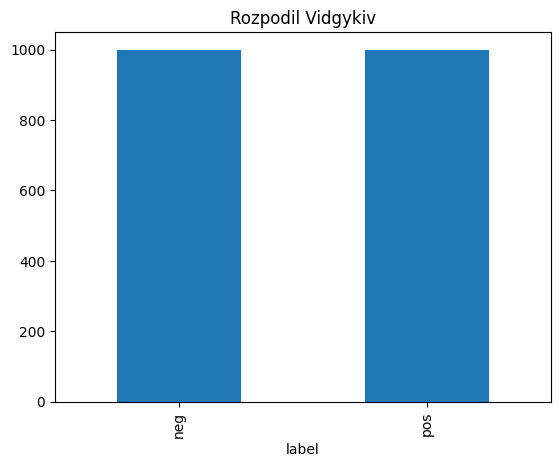

In [10]:
df['label'].value_counts().plot(kind='bar', title= 'Rozpodil Vidgykiv')

In [12]:
from numpy import vectorize
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['reviev'])
y = df['label']

In [13]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 24914)	1
  (0, 7714)	5
  (0, 24787)	1
  (0, 18023)	1
  (0, 17587)	1
  (0, 24547)	1
  (0, 557)	1
  (0, 20595)	1
  (0, 22318)	1
  (0, 21251)	1
  (0, 14723)	1
  (0, 22531)	1
  (0, 19406)	2
  (0, 13393)	2
  (0, 2090)	1
  (0, 10168)	1
  (0, 4222)	1
  (0, 15177)	1
  (0, 1290)	1
  (0, 1592)	1
  (0, 17682)	1
  (0, 22279)	1
  (0, 7791)	1
  (0, 14911)	1
  (0, 4264)	1
  :	:
  (1999, 16235)	1
  (1999, 24922)	1
  (1999, 21326)	1
  (1999, 25047)	1
  (1999, 9737)	2
  (1999, 4907)	1
  (1999, 2237)	1
  (1999, 6137)	1
  (1999, 1129)	1
  (1999, 5555)	1
  (1999, 15893)	1
  (1999, 12074)	1
  (1999, 5622)	3
  (1999, 24065)	2
  (1999, 14510)	2
  (1999, 21497)	1
  (1999, 19734)	1
  (1999, 16343)	1
  (1999, 16855)	1
  (1999, 14584)	1
  (1999, 8598)	1
  (1999, 19126)	1
  (1999, 3731)	1
  (1999, 11731)	1
  (1999, 21700)	1
0       neg
1       neg
2       neg
3       neg
4       neg
   

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accurancy:', accuracy_score(y_test, y_pred))

Accurancy: 0.8125


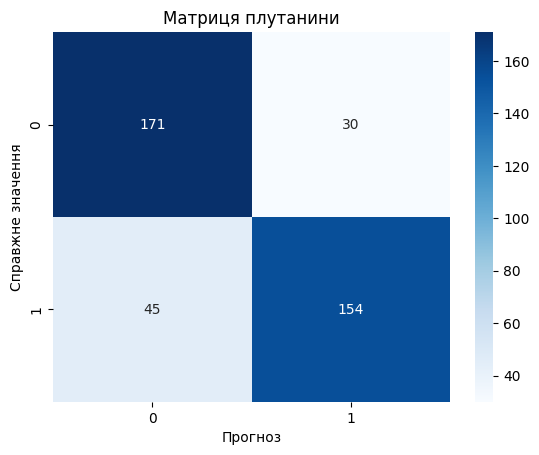

In [19]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Прогноз')
plt.ylabel('Справжне значення')
plt.title('Матриця плутанини')
plt.show()